# Characterizing the Influence of Wind Speed and Direction on Portable and Fixed DIMM seeing measurements

This is the companion notebook associated to TechNote sitcomtn-179

In [144]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os    
import pandas as pd
import numpy as np

from astropy.time import Time
import matplotlib.pyplot as plt

from lsst_efd_client import EfdClient
from lsst.summit.utils.efdUtils import getEfdData

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [145]:
# Some initialization
resample = '3min'  # DIMMs are providing measurements every ~1 minutes, we resample this to decrease the noise 
EFD_client = EfdClient("usdf_efd")

In [146]:
# Create directory for plots if it doesn't already exist
if not os.path.isdir("plots"):
    os.mkdir("plots")

## Some interesting DIMM data taking periods corresponding to different wind speeds and directions

 - 2025-11-27 -28: Wind speed > 4 m/s - Wind from NE
 - 2025-12-02 -03: Wind speed < 4 m/s = Wind direction mostly from NE - Somme occurrences of very low wind speed
 - 2025-12-03 -04: Decreasing wind speed - Wind direction from S
 - 2025-12-28 -29: Low wind speed - Changing direction
 - 2026-01-01 -02: Both DIMM disagree - Wind speed between 1 and 5 m/s - Wind direction from SSE
 - 2026-01-03 -04: Wind stops and change of direction

In [161]:
t_start = Time("2026-01-01 22:00:00")
t_end = Time("2026-01-02 12:00:00")

df_dimm_meas = getEfdData(
    EFD_client, "lsst.sal.DIMM.logevent_dimmMeasurement", begin=t_start, end=t_end)
df_dimm_meas.dropna(inplace=True)
df_dimm_meas = df_dimm_meas[df_dimm_meas["fwhm"]<5]   # Drop abnormally high fwhm

df_ess_airflow = getEfdData(
    EFD_client, "lsst.sal.ESS.airFlow", begin=t_start, end=t_end
)

# Determine the time window where we actually get DIMM measurements
start_dimm = df_dimm_meas.index[0]
end_dimm = df_dimm_meas.index[-1]

# Get wind measurements - salIndex 301 corresponds to the weather tower located on the calibration hill
airflow = df_ess_airflow[start_dimm:end_dimm][df_ess_airflow["salIndex"] == 301]

/tmp/ipykernel_154/1047469271.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  airflow = df_ess_airflow[start_dimm:end_dimm][df_ess_airflow["salIndex"] == 301]


In [162]:
# Define cut_1 and cut_2 to select DIMM-1 and DIMM-2 according to the salIndex
cut_1 = df_dimm_meas["salIndex"] == 1
cut_2 = df_dimm_meas["salIndex"] == 2

# Determine the time window where we actually get DIMM measurements
start_dimm = df_dimm_meas.index[0]
end_dimm = df_dimm_meas.index[-1]

# Compute resampled wind direction correctly (handling 0-360 boundary)
sin_mean = airflow['direction'].apply(lambda x: np.sin(np.radians(x))).resample(resample).mean()
cos_mean = airflow['direction'].apply(lambda x: np.cos(np.radians(x))).resample(resample).mean()
wind_direction = (np.degrees(np.arctan2(sin_mean, cos_mean)) + 360) % 360

# Build the combined dataframe
df = pd.concat([
    airflow["speed"].resample(resample).mean()                    .rename("wind_speed"),
    wind_direction                                                .rename("wind_direction"),
    df_dimm_meas["fwhm"][cut_1].resample(resample).mean()         .rename("dimm_1_fwhm"),
    df_dimm_meas["fwhm"][cut_2].resample(resample).mean()         .rename("dimm_2_fwhm"),
    df_dimm_meas["secz"][cut_1].resample(resample).mean()         .rename("dimm_1_airmass"),
    df_dimm_meas["secz"][cut_2].resample(resample).mean()         .rename("dimm_2_airmass"),
], axis=1)

# Drop rows where dimm_1 or dimm_2 have no values
df = df.dropna(subset=["dimm_1_fwhm", "dimm_2_fwhm"], how="any")

t_min = df.index[0]
t_max = df.index[-1]

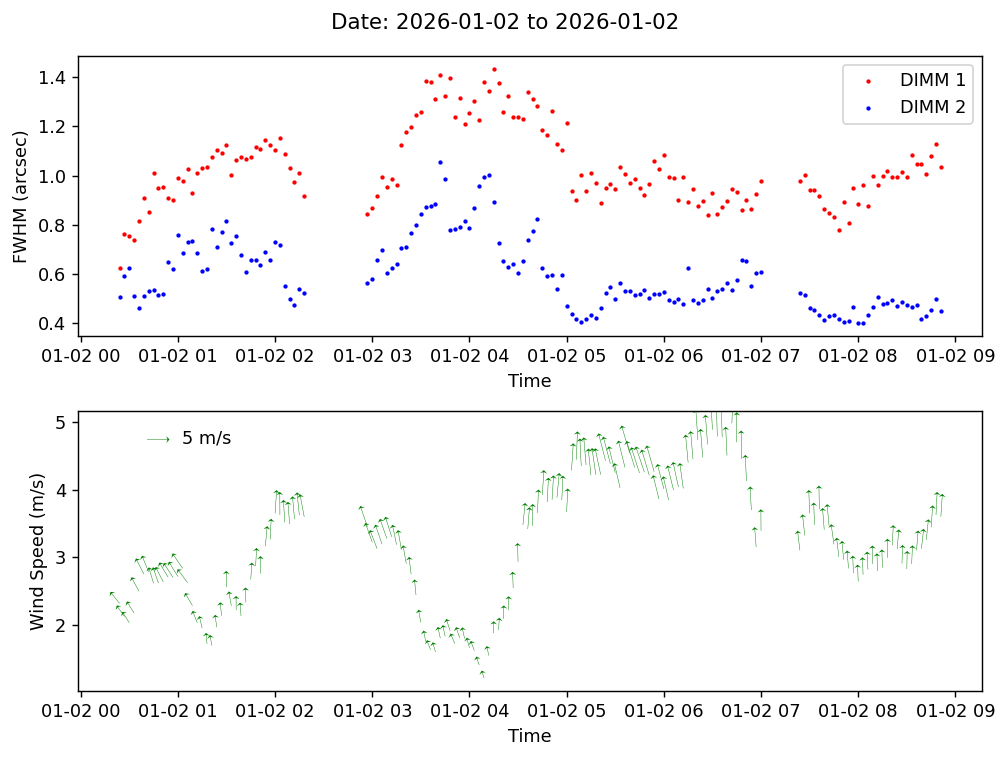

In [163]:
fig, ax = plt.subplots(2, 1, dpi=128, figsize=(8, 6))

ax[0].scatter(df.index, df["dimm_1_fwhm"], marker="o", s=2, color="red", label="DIMM 1")
ax[0].scatter(df.index, df["dimm_2_fwhm"], marker="o", s=2, color="blue", label="DIMM 2")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("FWHM (arcsec)")
ax[0].legend()

Q0 = ax[1].quiver(df.index, df["wind_speed"], df["wind_speed"] , df["wind_speed"], 
                  angles=270.0-df["wind_direction"], scale=15, scale_units="y", width=0.0005, 
                  headwidth=15, headlength=7, color="green") 
qk0 = ax[1].quiverkey(Q0, 0.1, 0.9, 5, '5 m/s', labelpos='E', coordinates='axes', color="green")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Wind Speed (m/s)")

# Add date
date_start = t_min.strftime("%Y-%m-%d")
date_end   = t_max.strftime("%Y-%m-%d")

fig.suptitle(f"Date: {date_start} to {date_end}")

fig.tight_layout()
plt.savefig(f"plots/dimm-1_dimm2-wind_{date_start}-{date_end}.png")

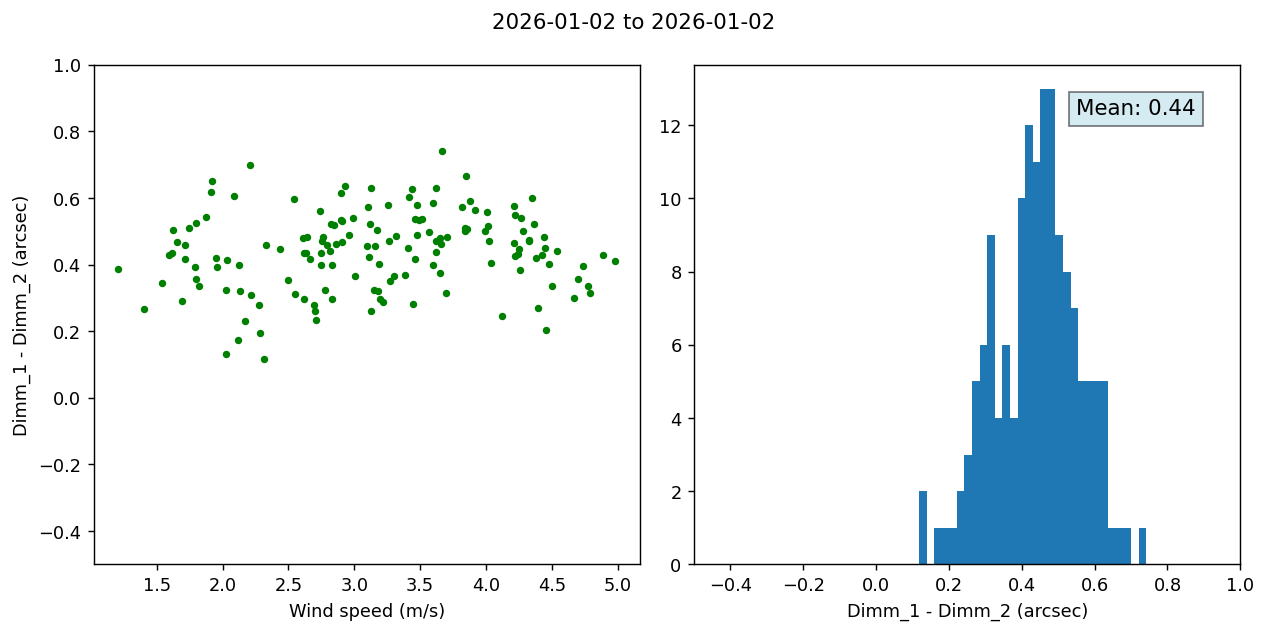

In [164]:
fig, ax = plt.subplots(1, 2, dpi=128, figsize=(10, 5))

ax[0].scatter(df["wind_speed"], df["dimm_1_fwhm"] - df["dimm_2_fwhm"], marker="o", s=10, color="green")
ax[0].set_ylabel("Dimm_1 - Dimm_2 (arcsec)")
ax[0].set_xlabel("Wind speed (m/s)")
#ax.set_xlim([0., 12.])
ax[0].set_ylim([-0.5, 1])

ax[1].hist(df["dimm_1_fwhm"] - df["dimm_2_fwhm"], bins=30)
ax[1].set_xlabel("Dimm_1 - Dimm_2 (arcsec)")
ax[1].set_xlim([-0.5, 1])

diff = np.mean(df["dimm_1_fwhm"] - df["dimm_2_fwhm"])
ax[1].text(0.70, 0.9, f'Mean: {diff:.2f}', transform=ax[1].transAxes,
           fontsize=12, bbox=dict(facecolor='lightblue', alpha=0.5))

# Add date
date_start = t_min.strftime("%Y-%m-%d")
date_end   = t_max.strftime("%Y-%m-%d")

fig.suptitle(f"{date_start} to {date_end}")

fig.tight_layout()
plt.savefig(f"plots/dimm_1-dimm_2-Vs-wind_res_{resample}_{date_start}-{date_end}.png")

In [165]:
print(f"Minimum wind speed: {np.min(df["wind_speed"]):.1f} m/s - Maximum wind speed: {np.max(df["wind_speed"]):.1f} m/s")
print(f"Average of DIMM-1 - DIMM-2 {diff:.2f} arcsec")

Minimum wind speed: 1.2 m/s - Maximum wind speed: 5.0 m/s
Average of DIMM-1 - DIMM-2 0.44 arcsec


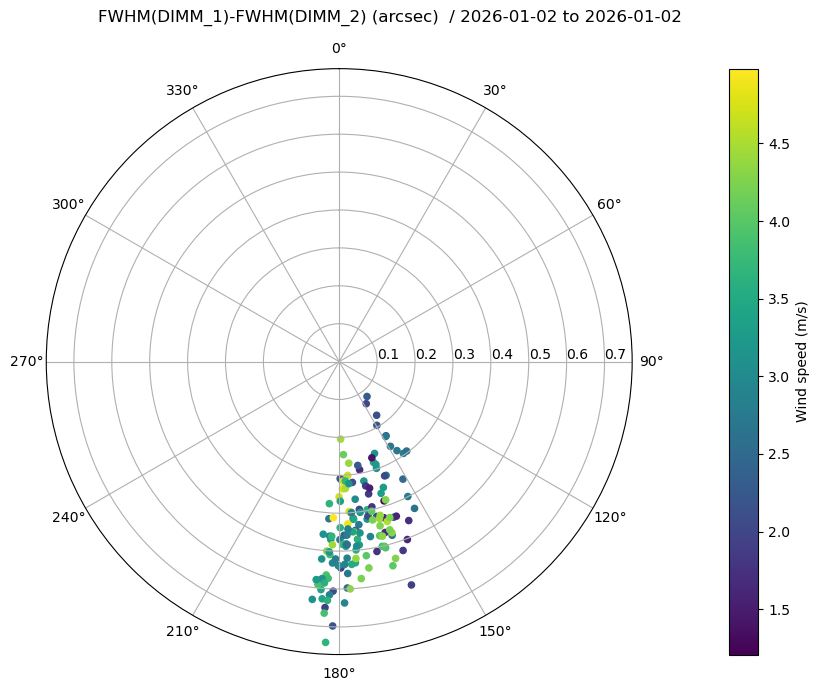

In [166]:
# Plot DIMM-1 - DIMM-2 in polar coordinates as a function of wind_direction
# color scale is wind_speed

wind_direction_rad = np.deg2rad(df["wind_direction"])

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, polar=True)

# Compass-like orientation
ax.set_theta_zero_location("N")  # 0° at North
ax.set_theta_direction(-1)       # Clockwise

# Set grid labels in degrees instead of radians
ax.set_thetagrids(range(0, 360, 30))  # every 30°


# Plot histogram bars on polar axis
sc = ax.scatter(wind_direction_rad, df["dimm_1_fwhm"]-df["dimm_2_fwhm"],
                c=df["wind_speed"], cmap='viridis', s=20)
ax.set_rlabel_position(90)

# Add a colorbar
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Wind speed (m/s)")

# Add date
date_start = t_min.strftime("%Y-%m-%d")
date_end   = t_max.strftime("%Y-%m-%d")

fig.suptitle(f"FWHM(DIMM_1)-FWHM(DIMM_2) (arcsec)  / {date_start} to {date_end}")
fig.tight_layout()
plt.savefig(f"plots/dimm_diff_polar_{date_start}-{date_end}.png")

/tmp/ipykernel_154/48660657.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 0.98], h_pad=0.5)


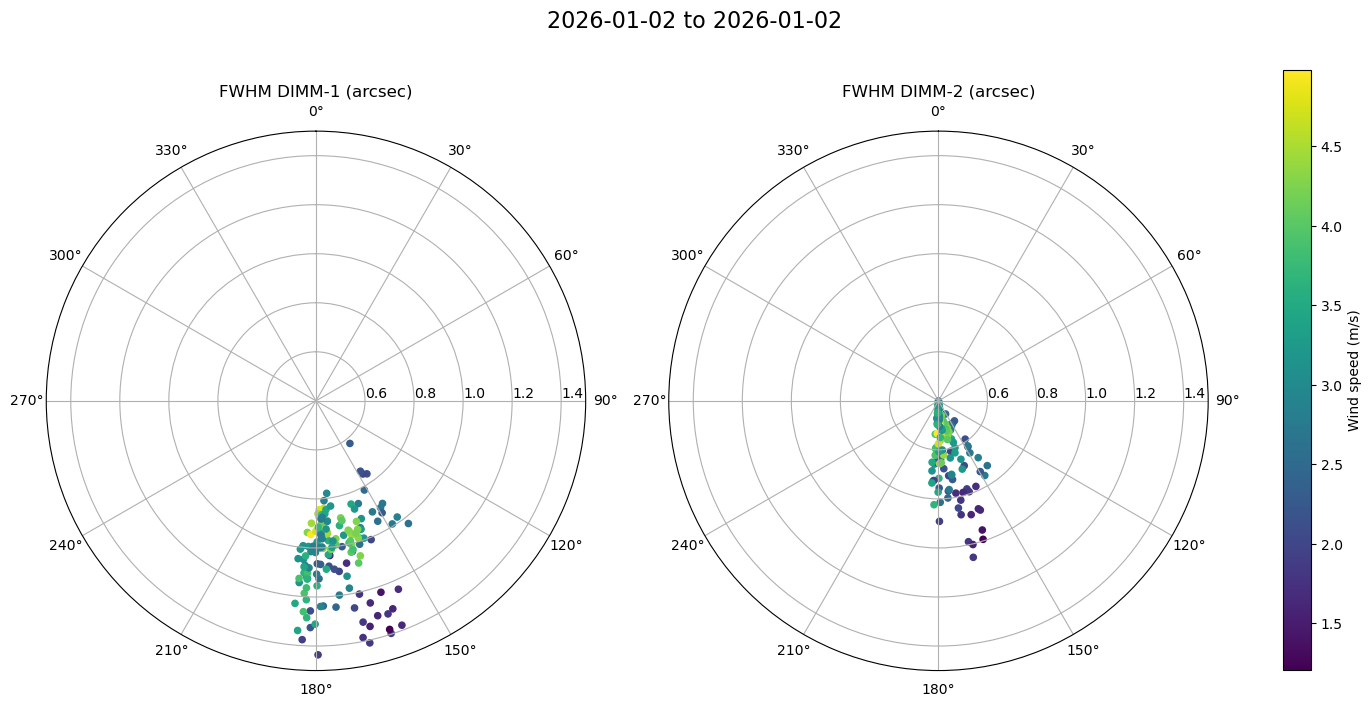

In [167]:
# Plot DIMM-1 and DIMM-2 FWHM in polar coordinates as a function of wind direction
# color scale is wind_speed

wind_direction_rad = np.deg2rad(df["wind_direction"])

fig = plt.figure(figsize=(14,12))

ax = []
pos = [121, 122]
for i in [0,1]:
    ax.append(fig.add_subplot(int(pos[i]), polar=True))
    
    # Compass-like orientation
    ax[i].set_theta_zero_location("N")  # 0° at North
    ax[i].set_theta_direction(-1)       # Clockwise
    
    # Set grid labels in degrees instead of radians
    ax[i].set_thetagrids(range(0, 360, 30))  # every 30°
    
    
    # Plot histogram bars on polar axis
    sc = ax[i].scatter(wind_direction_rad, df[f"dimm_{i+1}_fwhm"],
                    c=df["wind_speed"], cmap='viridis', s=20)
    ax[i].set_rlim(0.4, 1.5) 
    ax[i].set_rlabel_position(90)
    ax[i].set_title(f"FWHM DIMM-{i+1} (arcsec)")
    
    # Add a colorbar
#    cbar = plt.colorbar(sc, ax=ax[i], pad=0.1)
#   cbar.set_label("Wind speed (m/s)")
    
    # Add date
    date_start = t_min.strftime("%Y-%m-%d")
    date_end   = t_max.strftime("%Y-%m-%d")

cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5]) # [left, bottom, width, height]
fig.colorbar(sc, cax=cbar_ax, label="Wind speed (m/s)")

fig.suptitle(f"{date_start} to {date_end}", y=0.8, fontsize=16)

fig.tight_layout(rect=[0, 0, 0.9, 0.98], h_pad=0.5)
plt.savefig(f"plots/DIMM-1_DIMM-2_polar_{date_start}-{date_end}.png", bbox_inches='tight', pad_inches=0.1)

## Check boresight of bot DIMM

Both DIMM are operating independently so there is no reason for them to point to the same target. 

Unfortunately we cannot get the reference star coordinates in the EFD (values are wrong). 

In order to compare both DIMM pointings we use the airmass as a proxy and we assume that if the airmass is the same for both DIMM then they
are very likely pointing to the same reference star.

In [ ]:
fig, ax = plt.subplots(1, 1, dpi=128, figsize=(12, 5))
ax.scatter(df_dimm_meas.index[cut_1], df_dimm_meas["secz"][cut_1], marker="o", s=2, color="red", label="DIMM 1", alpha=0.5)
ax.scatter(df_dimm_meas.index[cut_2], df_dimm_meas["secz"][cut_2]+0.004, marker="o", s=2, color="blue", label="DIMM 2", alpha=0.5)
ax.set_xlabel("Time")
ax.set_ylabel("Airmass")
ax.legend()
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f"plots/airmass_{t_start.strftime("%Y-%m-%d")}-{t_end.strftime("%Y-%m-%d")}.png")